In [18]:
# Import Required Libraries
import pandas as pd
import numpy as np
import os
import json
from pathlib import Path
from typing import Dict, List, Tuple

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

In [19]:
# Define and verify paths to the results folders
base_path = Path(r"c:\Users\alexn\Documents\GitHub\SC-G5\delft_calliope")
median_results_path = base_path / "median_results"
sensitivity_results_path = base_path / "sensitivity_results"

# Configuration parameters
GEOTHERMAL_COP = 33  # Coefficient of Performance for geothermal heat plant

# Verify paths exist
print(f"Median results path exists: {median_results_path.exists()}")
print(f"Sensitivity results path exists: {sensitivity_results_path.exists()}")
print(f"Geothermal COP: {GEOTHERMAL_COP}")

# List available result runs
median_runs = sorted([d for d in median_results_path.iterdir() if d.is_dir()])
sensitivity_runs = sorted([d for d in sensitivity_results_path.iterdir() if d.is_dir()])

print(f"\nMedian result runs ({len(median_runs)}): {[d.name for d in median_runs]}")
print(f"Sensitivity result runs ({len(sensitivity_runs)}): {[d.name for d in sensitivity_runs]}")

Median results path exists: True
Sensitivity results path exists: True
Geothermal COP: 33

Median result runs (2): ['20260121_122454', '20260121_122457']
Sensitivity result runs (2): ['20260121_202912', '20260121_202918']


In [20]:
def load_scenario_data(results_path: Path, run_name: str) -> pd.DataFrame:
    """Load scenario summary CSV for a given run."""
    csv_path = results_path / run_name / "scenario_summary.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df['run_id'] = run_name
        return df
    else:
        print(f"Warning: {csv_path} not found")
        return pd.DataFrame()

# Load median results data
print("Loading median results...")
median_dfs = []
for run in median_runs:
    df = load_scenario_data(median_results_path, run.name)
    if not df.empty:
        median_dfs.append(df)
        print(f"  Loaded {run.name}: {len(df)} scenarios")

if median_dfs:
    median_data = pd.concat(median_dfs, ignore_index=True)
    print(f"\nTotal median scenarios loaded: {len(median_data)}")
    median_data.head()
else:
    print("No median data loaded")
    median_data = pd.DataFrame()

Loading median results...
  Loaded 20260121_122454: 72 scenarios

Total median scenarios loaded: 72


In [21]:
# Extract geothermal heat supply and COP from median results
# Column mapping for relevant fields
geothermal_col = 'results_summary_supply_geothermal_capacity_kW'
cop_col = 'technology_parameters_heat_pump_cop'
lv_elec_col = 'results_summary_supply_LV_electricity_capacity_kW'

# Check if columns exist in median data
if not median_data.empty:
    available_cols = median_data.columns.tolist()
    
    # Look for geothermal-related columns
    geothermal_cols = [col for col in available_cols if 'geothermal' in col.lower()]
    print(f"Geothermal-related columns found: {geothermal_cols}")
    
    # Look for LV electricity columns
    lv_cols = [col for col in available_cols if 'lv_electricity' in col.lower() or 'supply_LV_electricity' in col]
    print(f"LV electricity-related columns found: {lv_cols}")
    
    # Use adjusted geothermal if available, otherwise use original
    if 'results_summary_supply_geothermal_capacity_adjusted_kW' in available_cols:
        geothermal_col = 'results_summary_supply_geothermal_capacity_adjusted_kW'
    
    print(f"\nUsing geothermal column: {geothermal_col}")
    print(f"Using geothermal COP: {GEOTHERMAL_COP}")
    
    # Calculate geothermal heat divided by COP
    median_data['geothermal_heat_div_cop'] = median_data[geothermal_col] / GEOTHERMAL_COP
    
    print(f"\nMedian geothermal heat / COP statistics:")
    print(median_data['geothermal_heat_div_cop'].describe())

Geothermal-related columns found: ['results_summary_supply_geothermal_capacity_original_kW', 'results_summary_supply_geothermal_capacity_adjusted_kW', 'results_summary_supply_geothermal_additional_for_losses_kW', 'results_summary_supply_geothermal_capacity_kW']
LV electricity-related columns found: ['results_summary_supply_LV_electricity_capacity_kW', 'results_summary_supply_LV_electricity_capacity_original_kW', 'results_summary_supply_LV_electricity_capacity_adjusted_kW', 'results_summary_supply_LV_electricity_additional_for_losses_kW']

Using geothermal column: results_summary_supply_geothermal_capacity_adjusted_kW
Using geothermal COP: 33

Median geothermal heat / COP statistics:
count     48.000000
mean     222.654850
std       83.172808
min       75.844388
25%      171.679027
50%      211.300549
75%      264.880265
max      390.347903
Name: geothermal_heat_div_cop, dtype: float64


In [22]:
# Extract LV electricity supply from median results
if not median_data.empty:
    # Handle LV electricity column - check for different naming conventions
    lv_cols_available = [col for col in median_data.columns if 'LV_electricity' in col or 'lv_electricity' in col.lower()]
    
    if lv_cols_available:
        # Prefer adjusted values if available
        adjusted_cols = [col for col in lv_cols_available if 'adjusted' in col.lower()]
        if adjusted_cols:
            lv_elec_col = adjusted_cols[0]
        else:
            lv_elec_col = lv_cols_available[0]
        
        print(f"Using LV electricity column: {lv_elec_col}")
        
        # Handle NaN values (scenarios without LV electricity supply)
        median_data['lv_electricity_supply'] = median_data[lv_elec_col].fillna(0)
        
        print(f"\nMedian LV electricity supply statistics:")
        print(median_data['lv_electricity_supply'].describe())
    else:
        print("No LV electricity columns found, using zeros")
        median_data['lv_electricity_supply'] = 0

Using LV electricity column: results_summary_supply_LV_electricity_capacity_adjusted_kW

Median LV electricity supply statistics:
count      72.000000
mean      687.674133
std       894.728283
min         0.000000
25%         0.000000
50%       141.363006
75%      1300.845130
max      2961.339994
Name: lv_electricity_supply, dtype: float64


In [23]:
# Calculate combined energy supply (geothermal/COP + LV electricity)
if not median_data.empty:
    # Ensure both components are present and handle any NaN values
    median_data['geothermal_heat_div_cop'] = median_data['geothermal_heat_div_cop'].fillna(0)
    median_data['lv_electricity_supply'] = median_data['lv_electricity_supply'].fillna(0)
    
    median_data['combined_energy_supply_kW'] = (
        median_data['geothermal_heat_div_cop'] + median_data['lv_electricity_supply']
    )
    
    # Extract key scenario parameters
    parameter_cols = [
        'run_id', 'neighborhood', 'year', 'scenario', 'topology_source',
        'technology_parameters_heat_pump_cop',
        'results_summary_supply_geothermal_capacity_adjusted_kW',
        'results_summary_heat_pump_capacity_kW',
        'results_summary_total_heat_demand_kW',
        'lv_electricity_supply',
        'geothermal_heat_div_cop',
        'combined_energy_supply_kW'
    ]
    
    # Filter to only available columns
    available_param_cols = [col for col in parameter_cols if col in median_data.columns]
    
    median_summary = median_data[available_param_cols].copy()
    median_summary['result_type'] = 'median'
    
    print("Median Results Summary:")
    print(median_summary)
    print(f"\nCombined energy supply statistics (median):")
    print(median_data['combined_energy_supply_kW'].describe())

Median Results Summary:
             run_id     neighborhood  year              scenario  \
0   20260121_122454   multatulibuurt  2013      district_heating   
1   20260121_122454   multatulibuurt  2013      district_heating   
2   20260121_122454   multatulibuurt  2013  full_electrification   
3   20260121_122454   multatulibuurt  2013  full_electrification   
4   20260121_122454   multatulibuurt  2013                hybrid   
5   20260121_122454   multatulibuurt  2013                hybrid   
6   20260121_122454   multatulibuurt  2019      district_heating   
7   20260121_122454   multatulibuurt  2019      district_heating   
8   20260121_122454   multatulibuurt  2019  full_electrification   
9   20260121_122454   multatulibuurt  2019  full_electrification   
10  20260121_122454   multatulibuurt  2019                hybrid   
11  20260121_122454   multatulibuurt  2019                hybrid   
12  20260121_122454   multatulibuurt  2020      district_heating   
13  20260121_122454   mu

In [24]:
# Load and process sensitivity results similarly
print("Loading sensitivity results...")
sensitivity_dfs = []
for run in sensitivity_runs:
    df = load_scenario_data(sensitivity_results_path, run.name)
    if not df.empty:
        sensitivity_dfs.append(df)
        print(f"  Loaded {run.name}: {len(df)} scenarios")

if sensitivity_dfs:
    sensitivity_data = pd.concat(sensitivity_dfs, ignore_index=True)
    print(f"\nTotal sensitivity scenarios loaded: {len(sensitivity_data)}")
    
    # Perform same calculations for sensitivity data
    if 'results_summary_supply_geothermal_capacity_adjusted_kW' in sensitivity_data.columns:
        geothermal_col_sens = 'results_summary_supply_geothermal_capacity_adjusted_kW'
    else:
        geothermal_col_sens = 'results_summary_supply_geothermal_capacity_kW'
    
    # Use the defined GEOTHERMAL_COP variable
    sensitivity_data['geothermal_heat_div_cop'] = (
        sensitivity_data[geothermal_col_sens] / GEOTHERMAL_COP
    )
    
    # Handle LV electricity for sensitivity
    lv_cols_sens = [col for col in sensitivity_data.columns if 'LV_electricity' in col or 'lv_electricity' in col.lower()]
    if lv_cols_sens:
        adjusted_cols_sens = [col for col in lv_cols_sens if 'adjusted' in col.lower()]
        lv_elec_col_sens = adjusted_cols_sens[0] if adjusted_cols_sens else lv_cols_sens[0]
        sensitivity_data['lv_electricity_supply'] = sensitivity_data[lv_elec_col_sens].fillna(0)
    else:
        sensitivity_data['lv_electricity_supply'] = 0
    
    # Ensure both components are present and handle any NaN values
    sensitivity_data['geothermal_heat_div_cop'] = sensitivity_data['geothermal_heat_div_cop'].fillna(0)
    sensitivity_data['lv_electricity_supply'] = sensitivity_data['lv_electricity_supply'].fillna(0)
    
    # Calculate combined energy supply
    sensitivity_data['combined_energy_supply_kW'] = (
        sensitivity_data['geothermal_heat_div_cop'] + sensitivity_data['lv_electricity_supply']
    )
    
    # Create summary
    parameter_cols_sens = [
        'run_id', 'neighborhood', 'year', 'scenario', 'topology_source',
        'technology_parameters_heat_pump_cop',
        'scenario_info_spacing_m',
        geothermal_col_sens,
        'results_summary_heat_pump_capacity_kW',
        'results_summary_total_heat_demand_kW',
        'lv_electricity_supply',
        'geothermal_heat_div_cop',
        'combined_energy_supply_kW'
    ]
    
    available_param_cols_sens = [col for col in parameter_cols_sens if col in sensitivity_data.columns]
    
    sensitivity_summary = sensitivity_data[available_param_cols_sens].copy()
    sensitivity_summary['result_type'] = 'sensitivity'
    
    print("\nSensitivity Results Summary:")
    print(sensitivity_summary)
else:
    print("No sensitivity data loaded")
    sensitivity_summary = pd.DataFrame()

Loading sensitivity results...
  Loaded 20260121_202912: 30 scenarios

Total sensitivity scenarios loaded: 30

Sensitivity Results Summary:
             run_id    neighborhood  year              scenario  \
0   20260121_202912  multatulibuurt  2019      district_heating   
1   20260121_202912  multatulibuurt  2019  full_electrification   
2   20260121_202912  multatulibuurt  2019      district_heating   
3   20260121_202912  multatulibuurt  2019      district_heating   
4   20260121_202912  multatulibuurt  2019      district_heating   
5   20260121_202912  multatulibuurt  2019      district_heating   
6   20260121_202912  multatulibuurt  2019      district_heating   
7   20260121_202912  multatulibuurt  2019      district_heating   
8   20260121_202912  multatulibuurt  2019      district_heating   
9   20260121_202912  multatulibuurt  2019      district_heating   
10  20260121_202912  multatulibuurt  2019      district_heating   
11  20260121_202912  multatulibuurt  2019      district_

In [25]:
# Combine median and sensitivity results for comparison
if not median_summary.empty and not sensitivity_summary.empty:
    # Align columns for concatenation
    common_cols = list(set(median_summary.columns) & set(sensitivity_summary.columns))
    
    combined_results = pd.concat([
        median_summary[common_cols],
        sensitivity_summary[common_cols]
    ], ignore_index=True, sort=False)
    
    print(f"Combined Results Summary:")
    print(f"Total scenarios: {len(combined_results)}")
    print(f"\nBreakdown by result type:")
    print(combined_results['result_type'].value_counts())
    print(f"\nBreakdown by scenario type:")
    print(combined_results['scenario'].value_counts())
    
    # Display first few rows
    print("\nFirst 10 rows of combined results:")
    print(combined_results.head(10))
    
elif not median_summary.empty:
    combined_results = median_summary
    print("Only median results available")
elif not sensitivity_summary.empty:
    combined_results = sensitivity_summary
    print("Only sensitivity results available")
else:
    combined_results = pd.DataFrame()
    print("No results available")

Combined Results Summary:
Total scenarios: 102

Breakdown by result type:
result_type
median         72
sensitivity    30
Name: count, dtype: int64

Breakdown by scenario type:
scenario
district_heating        41
full_electrification    37
hybrid                  24
Name: count, dtype: int64

First 10 rows of combined results:
   results_summary_supply_geothermal_capacity_adjusted_kW           run_id  \
0                                        6234.853077       20260121_122454   
1                                        6308.920093       20260121_122454   
2                                                NaN       20260121_122454   
3                                                NaN       20260121_122454   
4                                        2947.888569       20260121_122454   
5                                        2936.265598       20260121_122454   
6                                        5760.339704       20260121_122454   
7                                        5835.4

In [26]:
# Export results to CSV files
output_dir = base_path / "outputs"
output_dir.mkdir(exist_ok=True)

# Export median results
if not median_summary.empty:
    median_output = output_dir / "energy_supply_median_results.csv"
    median_summary.to_csv(median_output, index=False)
    print(f"Median results exported to: {median_output}")
    print(f"  Rows: {len(median_summary)}")
    print(f"  Columns: {list(median_summary.columns)}")

# Export sensitivity results
if not sensitivity_summary.empty:
    sensitivity_output = output_dir / "energy_supply_sensitivity_results.csv"
    sensitivity_summary.to_csv(sensitivity_output, index=False)
    print(f"\nSensitivity results exported to: {sensitivity_output}")
    print(f"  Rows: {len(sensitivity_summary)}")
    print(f"  Columns: {list(sensitivity_summary.columns)}")

# Export combined results
if not combined_results.empty:
    combined_output = output_dir / "energy_supply_combined_results.csv"
    combined_results.to_csv(combined_output, index=False)
    print(f"\nCombined results exported to: {combined_output}")
    print(f"  Total scenarios: {len(combined_results)}")
    print(f"  Columns: {list(combined_results.columns)}")

Median results exported to: c:\Users\alexn\Documents\GitHub\SC-G5\delft_calliope\outputs\energy_supply_median_results.csv
  Rows: 72
  Columns: ['run_id', 'neighborhood', 'year', 'scenario', 'topology_source', 'technology_parameters_heat_pump_cop', 'results_summary_supply_geothermal_capacity_adjusted_kW', 'results_summary_heat_pump_capacity_kW', 'results_summary_total_heat_demand_kW', 'lv_electricity_supply', 'geothermal_heat_div_cop', 'combined_energy_supply_kW', 'result_type']

Sensitivity results exported to: c:\Users\alexn\Documents\GitHub\SC-G5\delft_calliope\outputs\energy_supply_sensitivity_results.csv
  Rows: 30
  Columns: ['run_id', 'neighborhood', 'year', 'scenario', 'topology_source', 'technology_parameters_heat_pump_cop', 'scenario_info_spacing_m', 'results_summary_supply_geothermal_capacity_adjusted_kW', 'results_summary_heat_pump_capacity_kW', 'results_summary_total_heat_demand_kW', 'lv_electricity_supply', 'geothermal_heat_div_cop', 'combined_energy_supply_kW', 'result_t

In [27]:
# Generate summary statistics
if not combined_results.empty:
    print("=" * 80)
    print("COMBINED RESULTS SUMMARY STATISTICS")
    print("=" * 80)
    
    # Overall statistics
    print("\nCombined Energy Supply (kW) - All Scenarios:")
    print(combined_results['combined_energy_supply_kW'].describe())
    
    # By result type
    print("\n" + "-" * 80)
    print("Statistics by Result Type:")
    for result_type in combined_results['result_type'].unique():
        subset = combined_results[combined_results['result_type'] == result_type]
        print(f"\n{result_type.upper()} ({len(subset)} scenarios):")
        print(f"  Mean combined energy supply: {subset['combined_energy_supply_kW'].mean():.2f} kW")
        print(f"  Std dev: {subset['combined_energy_supply_kW'].std():.2f} kW")
        print(f"  Min: {subset['combined_energy_supply_kW'].min():.2f} kW")
        print(f"  Max: {subset['combined_energy_supply_kW'].max():.2f} kW")
    
    # By scenario type
    print("\n" + "-" * 80)
    print("Statistics by Scenario Type:")
    for scenario_type in sorted(combined_results['scenario'].unique()):
        subset = combined_results[combined_results['scenario'] == scenario_type]
        print(f"\n{scenario_type} ({len(subset)} scenarios):")
        print(f"  Mean combined energy supply: {subset['combined_energy_supply_kW'].mean():.2f} kW")
        print(f"  Mean geothermal/COP: {subset['geothermal_heat_div_cop'].mean():.2f} kW")
        print(f"  Mean LV electricity: {subset['lv_electricity_supply'].mean():.2f} kW")
    
    print("\n" + "=" * 80)

COMBINED RESULTS SUMMARY STATISTICS

Combined Energy Supply (kW) - All Scenarios:
count     102.000000
mean      779.926122
std       736.968742
min       157.832816
25%       191.791373
50%       377.183369
75%      1252.712545
max      2961.339994
Name: combined_energy_supply_kW, dtype: float64

--------------------------------------------------------------------------------
Statistics by Result Type:

MEDIAN (72 scenarios):
  Mean combined energy supply: 836.11 kW
  Std dev: 796.75 kW
  Min: 157.83 kW
  Max: 2961.34 kW

SENSITIVITY (30 scenarios):
  Mean combined energy supply: 645.08 kW
  Std dev: 557.43 kW
  Min: 158.95 kW
  Max: 1706.25 kW

--------------------------------------------------------------------------------
Statistics by Scenario Type:

district_heating (41 scenarios):
  Mean combined energy supply: 213.23 kW
  Mean geothermal/COP: 213.23 kW
  Mean LV electricity: 0.00 kW

full_electrification (37 scenarios):
  Mean combined energy supply: 1627.76 kW
  Mean geotherma

Neighborhoods: ['holstbuurt', 'multatulibuurt', 'mythologiebuurt', 'poptahofzuid']
Scenarios included: district_heating, full_electrification
Number of neighborhoods: 4
Note: Multatulibuurt uses only median results


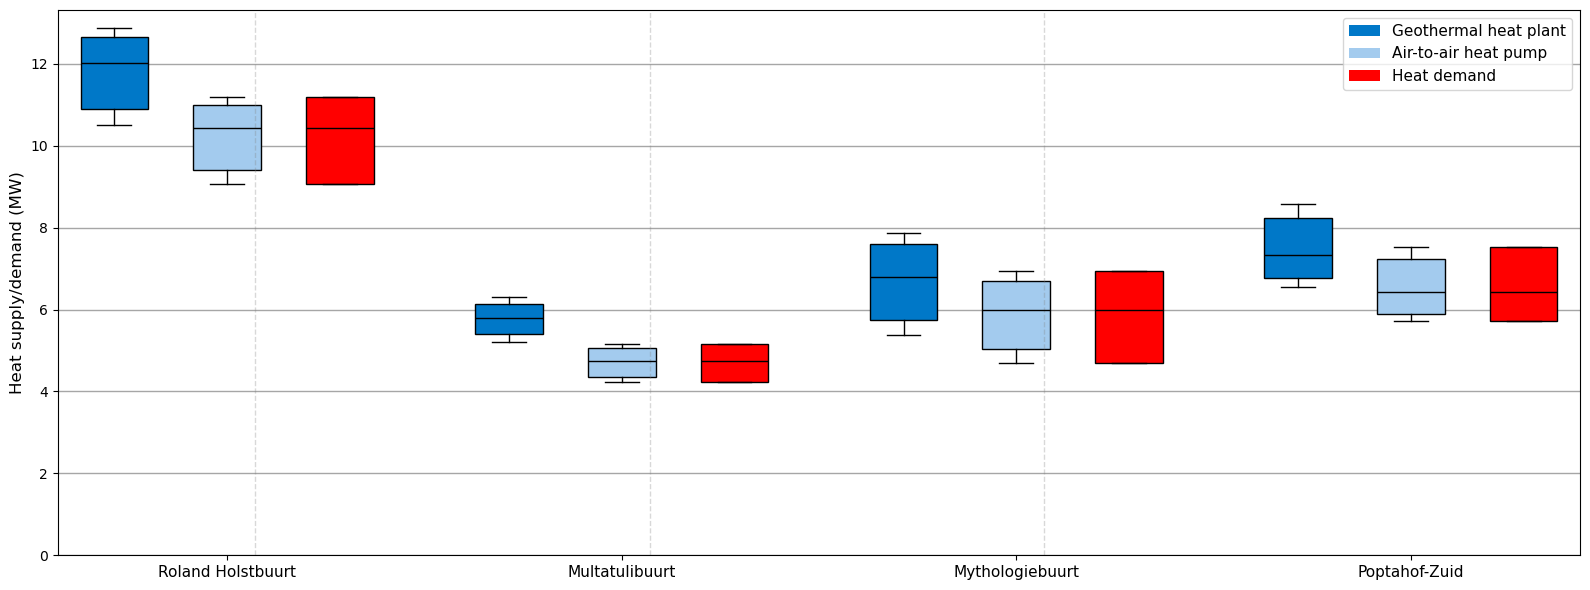

Boxplot visualization complete!


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Prepare data for boxplot visualization using matplotlib
if not combined_results.empty:
    # Filter out hybrid scenarios
    filtered_results = combined_results[combined_results['scenario'].isin(['district_heating', 'full_electrification'])].copy()
    
    # For multatulibuurt, only use median results
    multa_mask = filtered_results['neighborhood'] == 'multatulibuurt'
    filtered_results.loc[multa_mask, :] = filtered_results.loc[multa_mask & (filtered_results['result_type'] == 'median'), :]
    filtered_results = filtered_results.dropna(how='all')
    
    neighborhoods = sorted(filtered_results['neighborhood'].unique())
    
    print(f"Neighborhoods: {neighborhoods}")
    print(f"Scenarios included: district_heating, full_electrification")
    print(f"Number of neighborhoods: {len(neighborhoods)}")
    print(f"Note: Multatulibuurt uses only median results")
    
    # Check if required columns exist
    required_cols = [
        'results_summary_supply_geothermal_capacity_adjusted_kW',
        'results_summary_heat_pump_capacity_kW',
        'results_summary_total_heat_demand_kW'
    ]
    missing_cols = [col for col in required_cols if col not in filtered_results.columns]
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}")
    
    # Define colors
    color_dh = '#0078c8'
    color_fe = '#a3cbee'
    color_demand = 'red'
    
    # Neighborhood name mapping
    neighborhood_name_map = {
        'multatulibuurt': 'Multatulibuurt',
        'holstbuurt': 'Roland Holstbuurt',
        'poptahofzuid': 'Poptahof-Zuid'
    }
    
    # Prepare data for all neighborhoods in a single plot
    box_data = []
    box_positions = []
    colors = []
    neighborhood_centers = []
    
    pos = 1
    for neighborhood in neighborhoods:
        neighborhood_data = filtered_results[filtered_results['neighborhood'] == neighborhood]
        group_start = pos
        
        # District heating - geothermal capacity
        dh_data = neighborhood_data[neighborhood_data['scenario'] == 'district_heating']
        if len(dh_data) > 0 and 'results_summary_supply_geothermal_capacity_adjusted_kW' in dh_data.columns:
            capacity_dh = dh_data['results_summary_supply_geothermal_capacity_adjusted_kW'].dropna().values / 1000  # Convert kW to MW
            if len(capacity_dh) > 0:
                box_data.append(capacity_dh)
                box_positions.append(pos)
                colors.append(color_dh)
                pos += 1
        
        # Full electrification - heat pump capacity
        fe_data = neighborhood_data[neighborhood_data['scenario'] == 'full_electrification']
        if len(fe_data) > 0 and 'results_summary_heat_pump_capacity_kW' in fe_data.columns:
            capacity_fe = fe_data['results_summary_heat_pump_capacity_kW'].dropna().values / 1000  # Convert kW to MW
            if len(capacity_fe) > 0:
                box_data.append(capacity_fe)
                box_positions.append(pos)
                colors.append(color_fe)
                pos += 1
        
        # Heat demand (combine from both scenarios since it's the same)
        heat_demand = neighborhood_data['results_summary_total_heat_demand_kW'].dropna().values / 1000  # Convert kW to MW
        if len(heat_demand) > 0:
            box_data.append(heat_demand)
            box_positions.append(pos)
            colors.append(color_demand)
            pos += 1
        
        # Calculate center of neighborhood group
        group_end = pos - 1
        neighborhood_centers.append(((group_start + group_end) / 2, neighborhood))
        pos += 0.5  # Reduce space between neighborhood groups
    
    # Create single figure
    if len(box_data) > 0:
        fig, ax = plt.subplots(figsize=(16, 6))
        
        bp = ax.boxplot(box_data, positions=box_positions, patch_artist=True, widths=0.6)
        
        # Color the boxes
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        
        # Change median line color to black
        for median in bp['medians']:
            median.set(color='black', linewidth=1)
        
        # Set y-axis to start from zero (linear scale)
        ax.set_ylim(bottom=0)
        
        # Set x-axis ticks and labels to neighborhood names
        neighborhood_ticks = [center for center, _ in neighborhood_centers]
        neighborhood_labels = [neighborhood_name_map.get(name, name.replace('_', ' ').title()) for _, name in neighborhood_centers]
        ax.set_xticks(neighborhood_ticks)
        ax.set_xticklabels(neighborhood_labels, fontsize=11)
        
        # Add neighborhood separators
        for i in range(len(neighborhood_centers) - 1):
            separator_pos = neighborhood_centers[i][0] + 0.25
            ax.axvline(x=separator_pos, color='gray', linestyle='--', alpha=0.3, linewidth=1)
        
        # Add grid - prominent and easy to read
        ax.grid(axis='y', alpha=0.7, linestyle='-', linewidth=1.0, color='gray')
        ax.set_axisbelow(True)
        
        # Add legend
        legend_elements = [
            Patch(facecolor=color_dh, label='Geothermal heat plant'),
            Patch(facecolor=color_fe, label='Air-to-air heat pump'),
            Patch(facecolor=color_demand, label='Heat demand')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
        
        # Format plot
        ax.set_ylabel('Heat supply/demand (MW)', fontsize=12)
        ax.tick_params(axis='y', labelsize=10)
        
        plt.tight_layout()
        plt.show()
        
        print("Boxplot visualization complete!")
    else:
        print("No data available for visualization")

In [29]:
# Prepare data for power draw boxplot using median results only
# Power draw refers to LV electricity capacity (electrical power demand)

if not median_data.empty:
    # Filter to only median results (as requested)
    median_only = median_data.copy()
    
    # Include all three scenario types: district_heating, full_electrification, and hybrid
    power_draw_results = median_only[
        median_only['scenario'].isin(['district_heating', 'full_electrification', 'hybrid'])
    ].copy()
    
    # Identify the correct LV electricity column
    lv_power_cols = [col for col in power_draw_results.columns 
                     if 'LV_electricity' in col or 'lv_electricity' in col.lower()]
    
    # Prefer adjusted values if available
    adjusted_lv_cols = [col for col in lv_power_cols if 'adjusted' in col.lower()]
    if adjusted_lv_cols:
        lv_power_col = adjusted_lv_cols[0]
    elif lv_power_cols:
        lv_power_col = lv_power_cols[0]
    else:
        lv_power_col = 'results_summary_supply_LV_electricity_capacity_kW'
    
    print(f"Using LV electricity column: {lv_power_col}")
    print(f"\nPower Draw Analysis (Median Results Only):")
    print(f"Total scenarios: {len(power_draw_results)}")
    print(f"Neighborhoods: {sorted(power_draw_results['neighborhood'].unique())}")
    print(f"Scenarios: {sorted(power_draw_results['scenario'].unique())}")
    
    # Extract power draw data with scenario-specific calculations
    # For district heating and hybrid: combine geothermal/COP + LV electricity
    # For full electrification: use LV electricity only
    power_draw_results['power_draw_kW'] = power_draw_results[lv_power_col].fillna(0)
    
    # For district heating and hybrid scenarios, add geothermal/COP
    geothermal_col = 'results_summary_supply_geothermal_capacity_adjusted_kW'
    
    # Create mask for district heating and hybrid scenarios
    dh_hybrid_mask = power_draw_results['scenario'].isin(['district_heating', 'hybrid'])
    
    # Add geothermal contribution divided by COP for these scenarios
    power_draw_results.loc[dh_hybrid_mask, 'power_draw_kW'] = (
        power_draw_results.loc[dh_hybrid_mask, lv_power_col].fillna(0) +
        (power_draw_results.loc[dh_hybrid_mask, geothermal_col].fillna(0) / GEOTHERMAL_COP)
    )
    
    print(f"\nPower Draw Statistics (kW):")
    print(power_draw_results['power_draw_kW'].describe())
    print(f"\nBreakdown by scenario:")
    for scenario in sorted(power_draw_results['scenario'].unique()):
        subset = power_draw_results[power_draw_results['scenario'] == scenario]
        print(f"  {scenario}: mean={subset['power_draw_kW'].mean():.2f} kW, "
              f"min={subset['power_draw_kW'].min():.2f} kW, "
              f"max={subset['power_draw_kW'].max():.2f} kW")


Using LV electricity column: results_summary_supply_LV_electricity_capacity_adjusted_kW

Power Draw Analysis (Median Results Only):
Total scenarios: 72
Neighborhoods: ['holstbuurt', 'multatulibuurt', 'mythologiebuurt', 'poptahofzuid']
Scenarios: ['district_heating', 'full_electrification', 'hybrid']

Power Draw Statistics (kW):
count      72.000000
mean      836.110700
std       796.751051
min       157.832816
25%       222.480666
50%       457.707795
75%      1300.845130
max      2961.339994
Name: power_draw_kW, dtype: float64

Breakdown by scenario:
  district_heating: mean=240.48 kW, min=157.83 kW, max=390.35 kW
  full_electrification: mean=1826.90 kW, min=1093.10 kW, max=2961.34 kW
  hybrid: mean=440.96 kW, min=173.41 kW, max=773.74 kW


Creating power draw boxplot for 4 neighborhoods and 3 scenarios


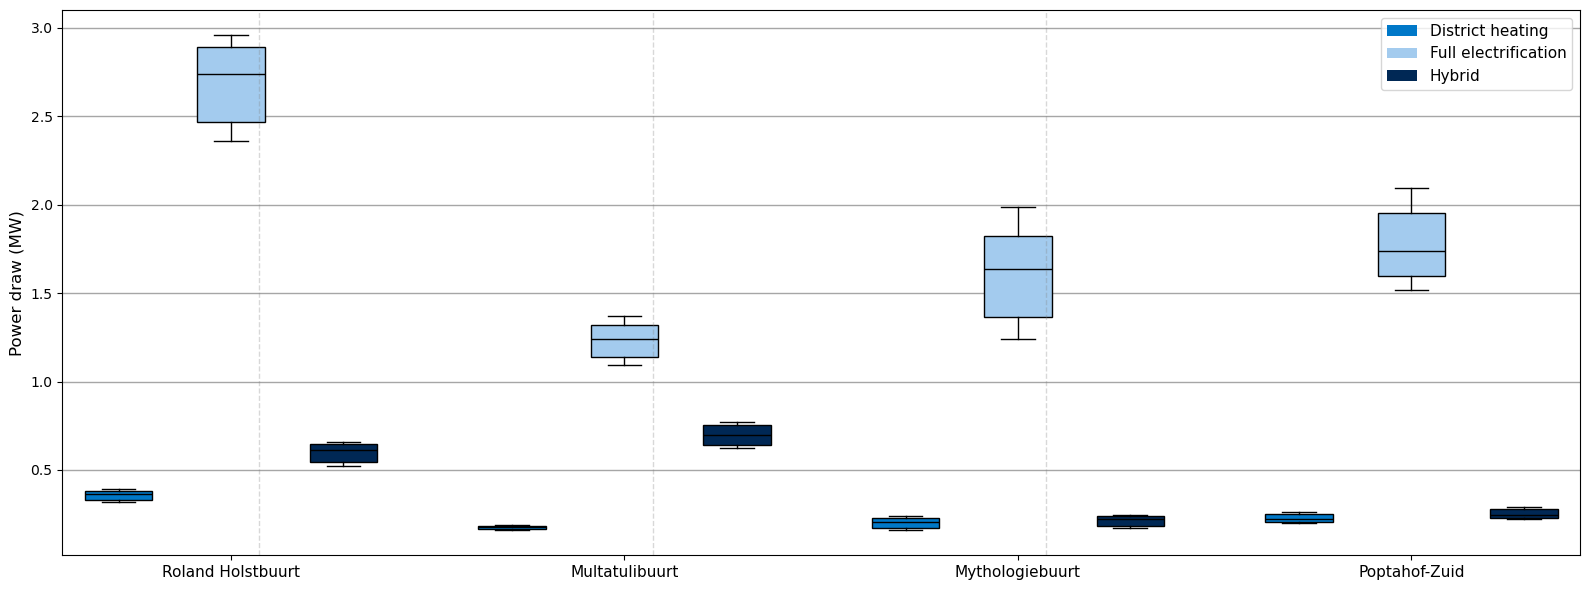

Power draw boxplot visualization complete!


In [30]:
# Create boxplot for power draw across neighborhoods and scenarios
if not power_draw_results.empty:
    neighborhoods = sorted(power_draw_results['neighborhood'].unique())
    scenarios = ['district_heating', 'full_electrification', 'hybrid']
    
    print(f"Creating power draw boxplot for {len(neighborhoods)} neighborhoods and {len(scenarios)} scenarios")
    
    # Define colors for each scenario
    colors_scenario = {
        'district_heating': '#0078c8',      # Blue
        'full_electrification': '#a3cbee',  # Light blue
        'hybrid': '#002855'                 # Dark blue
    }
    
    # Neighborhood name mapping
    neighborhood_name_map = {
        'multatulibuurt': 'Multatulibuurt',
        'holstbuurt': 'Roland Holstbuurt',
        'poptahofzuid': 'Poptahof-Zuid'
    }
    
    # Prepare data for all neighborhoods in a single plot
    box_data = []
    box_positions = []
    colors = []
    neighborhood_centers = []
    scenario_labels = []
    
    pos = 1
    for neighborhood in neighborhoods:
        neighborhood_data = power_draw_results[power_draw_results['neighborhood'] == neighborhood]
        group_start = pos
        
        for scenario in scenarios:
            scenario_data = neighborhood_data[neighborhood_data['scenario'] == scenario]
            if len(scenario_data) > 0:
                power_draw = scenario_data['power_draw_kW'].dropna().values / 1000  # Convert to MW
                if len(power_draw) > 0:
                    box_data.append(power_draw)
                    box_positions.append(pos)
                    colors.append(colors_scenario[scenario])
                    scenario_labels.append(scenario.replace('_', ' ').title())
                    pos += 1
        
        # Calculate center of neighborhood group
        group_end = pos - 1
        neighborhood_centers.append(((group_start + group_end) / 2, neighborhood))
        pos += 0.5  # Space between neighborhood groups
    
    # Create figure with power draw boxplot
    if len(box_data) > 0:
        fig, ax = plt.subplots(figsize=(16, 6))
        
        bp = ax.boxplot(box_data, positions=box_positions, patch_artist=True, widths=0.6)
        
        # Color the boxes
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        
        # Change median line color to black
        for median in bp['medians']:
            median.set(color='black', linewidth=1)
        
        # Set y-axis to logarithmic scale
        
        # Set x-axis ticks and labels to neighborhood names
        neighborhood_ticks = [center for center, _ in neighborhood_centers]
        neighborhood_labels = [neighborhood_name_map.get(name, name.replace('_', ' ').title()) 
                              for _, name in neighborhood_centers]
        ax.set_xticks(neighborhood_ticks)
        ax.set_xticklabels(neighborhood_labels, fontsize=11)
        
        # Add neighborhood separators
        for i in range(len(neighborhood_centers) - 1):
            separator_pos = neighborhood_centers[i][0] + 0.25
            ax.axvline(x=separator_pos, color='gray', linestyle='--', alpha=0.3, linewidth=1)
        
        # Add grid
        ax.grid(axis='y', alpha=0.7, linestyle='-', linewidth=1.0, color='gray')
        ax.set_axisbelow(True)
        
        # Add legend
        legend_elements = [
            Patch(facecolor=colors_scenario['district_heating'], label='District heating'),
            Patch(facecolor=colors_scenario['full_electrification'], label='Full electrification'),
            Patch(facecolor=colors_scenario['hybrid'], label='Hybrid')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
        
        # Format plot
        ax.set_ylabel('Power draw (MW)', fontsize=12)
        ax.tick_params(axis='y', labelsize=10)
        #ax.set_title('Electrical Power Draw by Neighborhood and Scenario (Median Results)', fontsize=13, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        print("Power draw boxplot visualization complete!")
    else:
        print("No data available for power draw visualization")
else:
    print("No power draw data available")

In [31]:
# Prepare sensitivity data for Multatulibuurt analysis
# Extract all heat parameters (district heating) and electricity parameters (full electrification)

if not sensitivity_data.empty:
    # Filter for Multatulibuurt neighborhood only
    multa_sensitivity = sensitivity_data[sensitivity_data['neighborhood'] == 'multatulibuurt'].copy()
    
    print(f"Multatulibuurt sensitivity analysis data:")
    print(f"Total scenarios: {len(multa_sensitivity)}")
    print(f"Scenarios: {sorted(multa_sensitivity['scenario'].unique())}")
    
    # List all parameters in the data
    all_params = multa_sensitivity.columns.tolist()
    
    # Identify heat-related parameters (for district heating)
    heat_params_mapping = {
        'technology_parameters_heat_substation_eff': 'Substation Efficiency',
        'postprocessing_parameters_pipe_sizing_heat_capacity': 'Heat Capacity',
        'postprocessing_parameters_pipe_sizing_delta_T': 'ΔT (°C)',
        'postprocessing_parameters_pipe_sizing_flow_speed': 'Flow Speed (m/s)',
        'postprocessing_parameters_distance_factors_Heat transmission main': 'Distance Factor (Heat Trans Main)',
        'postprocessing_parameters_distance_factors_LQ heat distribution main': 'Distance Factor (Heat Dist Main)',
        'postprocessing_parameters_distance_factors_LQ heat distribution secondary': 'Distance Factor (Heat Dist Sec)',
        'postprocessing_parameters_heat_loss_rates_Heat transmission main': 'Heat Loss Rate (Trans Main)',
        'postprocessing_parameters_heat_loss_rates_LQ heat distribution main': 'Heat Loss Rate (Dist Main)',
        'postprocessing_parameters_heat_loss_rates_LQ heat distribution secondary': 'Heat Loss Rate (Dist Sec)',
    }
    
    # Identify electricity-related parameters (for full electrification)
    elec_params_mapping = {
        'technology_parameters_heat_pump_cop': 'Heat Pump COP',
        'postprocessing_parameters_distance_factors_LV electricity distribution main': 'Distance Factor (Elec Dist Main)',
        'postprocessing_parameters_distance_factors_LV electricity distribution secondary': 'Distance Factor (Elec Dist Sec)',
        'postprocessing_parameters_electricity_resistance_rates_LV electricity distribution main': 'Elec Resistance (Main)',
        'postprocessing_parameters_electricity_resistance_rates_LV electricity distribution secondary': 'Elec Resistance (Sec)',
    }
    
    # Find which parameters actually exist in the data
    heat_params_available = {k: v for k, v in heat_params_mapping.items() if k in multa_sensitivity.columns}
    elec_params_available = {k: v for k, v in elec_params_mapping.items() if k in multa_sensitivity.columns}
    
    print(f"\nAvailable heat parameters: {list(heat_params_available.values())}")
    print(f"Available electricity parameters: {list(elec_params_available.values())}")
    
    # Separate data by scenario
    dh_sensitivity = multa_sensitivity[multa_sensitivity['scenario'] == 'district_heating'].copy()
    fe_sensitivity = multa_sensitivity[multa_sensitivity['scenario'] == 'full_electrification'].copy()
    
    print(f"\nDistrict heating sensitivity scenarios: {len(dh_sensitivity)}")
    print(f"Full electrification sensitivity scenarios: {len(fe_sensitivity)}")


Multatulibuurt sensitivity analysis data:
Total scenarios: 30
Scenarios: ['district_heating', 'full_electrification']

Available heat parameters: ['Substation Efficiency', 'Heat Capacity', 'ΔT (°C)', 'Flow Speed (m/s)', 'Distance Factor (Heat Trans Main)', 'Distance Factor (Heat Dist Main)', 'Distance Factor (Heat Dist Sec)', 'Heat Loss Rate (Trans Main)', 'Heat Loss Rate (Dist Main)', 'Heat Loss Rate (Dist Sec)']
Available electricity parameters: ['Heat Pump COP', 'Distance Factor (Elec Dist Main)', 'Distance Factor (Elec Dist Sec)', 'Elec Resistance (Main)', 'Elec Resistance (Sec)']

District heating sensitivity scenarios: 17
Full electrification sensitivity scenarios: 13



SENSITIVITY ANALYSIS: Substation Efficiency vs Geothermal Capacity

Parameter: Substation Efficiency
Analyzing values: [0.81, 0.9, 0.99]

  Low (0.81): n=1, mean=6.39 MW, std=0.00 MW
  Median (0.9): n=1, value=5.76 MW (from baseline median run, 2019, stedin)
  High (0.99): n=1, mean=5.25 MW, std=0.00 MW

Combined Summary (all parameter values):
  Total data points: 3
  Mean: 5.80 MW
  Median: 5.76 MW
  Std Dev: 0.47 MW
  Min: 5.25 MW
  Max: 6.39 MW
  Range: 1.14 MW


C:\Users\alexn\AppData\Local\Temp\ipykernel_11940\4053779919.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([all_geothermal], labels=['Substation Efficiency\nSensitivity Range'],


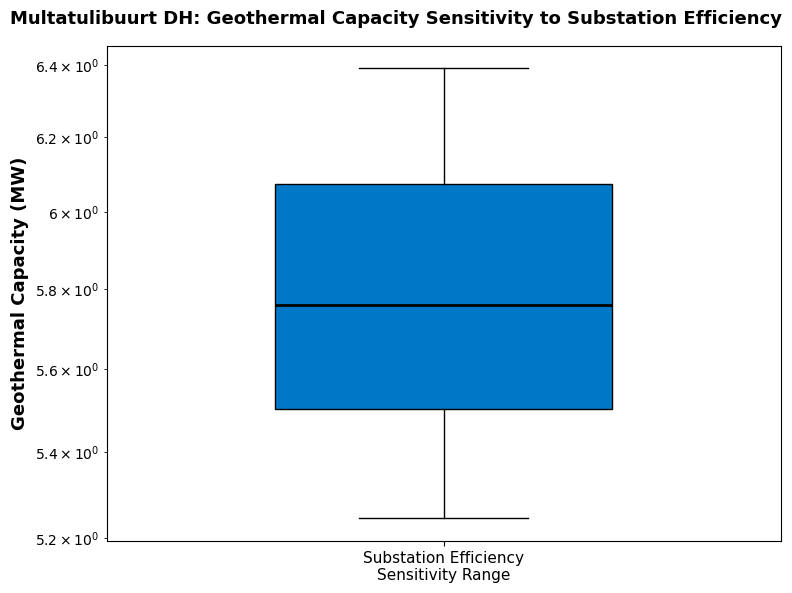


Sensitivity analysis complete!


In [32]:
# Sensitivity Analysis: Substation Efficiency vs Geothermal Capacity (District Heating)
# Single boxplot combining all outcomes across the parameter range

if not dh_sensitivity.empty and not median_data.empty:
    print("\n" + "="*80)
    print("SENSITIVITY ANALYSIS: Substation Efficiency vs Geothermal Capacity")
    print("="*80)
    
    substation_eff_col = 'technology_parameters_heat_substation_eff'
    
    if substation_eff_col in dh_sensitivity.columns:
        # Get the three specific efficiency values
        param_values = [0.81, 0.9, 0.99]  # Low, Median, High
        all_geothermal = []
        
        print(f"\nParameter: Substation Efficiency")
        print(f"Analyzing values: {param_values}\n")
        
        for i, param_value in enumerate(param_values):
            if param_value == 0.9:
                # For median, use the baseline median run (Multatulibuurt, DH, 2019, stedin topology)
                median_multa_dh = median_data[
                    (median_data['neighborhood'] == 'multatulibuurt') & 
                    (median_data['scenario'] == 'district_heating') &
                    (median_data['year'] == 2019) &
                    (median_data['topology_source'] == 'stedin')
                ]
                
                if not median_multa_dh.empty:
                    geothermal_capacity = median_multa_dh['results_summary_supply_geothermal_capacity_adjusted_kW'].dropna().values / 1000
                    all_geothermal.extend(geothermal_capacity)
                    print(f"  Median ({param_value}): n={len(geothermal_capacity)}, "
                          f"value={geothermal_capacity.mean():.2f} MW (from baseline median run, 2019, stedin)")
                else:
                    print(f"  No baseline median run found for Multatulibuurt DH with stedin topology")
            else:
                # For low and high, use sensitivity data
                param_data = dh_sensitivity[dh_sensitivity[substation_eff_col] == param_value]
                geothermal_capacity = param_data['results_summary_supply_geothermal_capacity_adjusted_kW'].dropna().values / 1000
                
                if len(geothermal_capacity) > 0:
                    all_geothermal.extend(geothermal_capacity)
                    label_text = 'Low' if param_value == 0.81 else 'High'
                    print(f"  {label_text} ({param_value}): n={len(geothermal_capacity)}, "
                          f"mean={geothermal_capacity.mean():.2f} MW, "
                          f"std={geothermal_capacity.std():.2f} MW")
                else:
                    print(f"  No data for value {param_value}")
        
        # Create single boxplot with all combined data
        if len(all_geothermal) > 0:
            fig, ax = plt.subplots(figsize=(8, 6))
            
            bp = ax.boxplot([all_geothermal], labels=['Substation Efficiency\nSensitivity Range'], 
                           patch_artist=True, widths=0.5)
            
            # Color the box with blue
            for patch in bp['boxes']:
                patch.set_facecolor('#0078c8')
            
            # Change median line color to black
            for median in bp['medians']:
                median.set(color='black', linewidth=2)
            
            # Set y-axis to logarithmic scale
            ax.set_yscale('log')
            
            # Add grid
            ax.grid(axis='y', alpha=0.7, linestyle='-', linewidth=1.0, color='gray')
            ax.set_axisbelow(True)
            
            # Format plot
            ax.set_ylabel('Geothermal Capacity (MW)', fontsize=13, fontweight='bold')
            ax.tick_params(axis='both', labelsize=11)
            
            # Print summary statistics
            print(f"\nCombined Summary (all parameter values):")
            print(f"  Total data points: {len(all_geothermal)}")
            print(f"  Mean: {np.mean(all_geothermal):.2f} MW")
            print(f"  Median: {np.median(all_geothermal):.2f} MW")
            print(f"  Std Dev: {np.std(all_geothermal):.2f} MW")
            print(f"  Min: {np.min(all_geothermal):.2f} MW")
            print(f"  Max: {np.max(all_geothermal):.2f} MW")
            print(f"  Range: {np.max(all_geothermal) - np.min(all_geothermal):.2f} MW")
            
            fig.suptitle('Multatulibuurt DH: Geothermal Capacity Sensitivity to Substation Efficiency', 
                        fontsize=13, fontweight='bold')
            plt.tight_layout()
            plt.show()
            
            print("\n" + "="*80)
            print("Sensitivity analysis complete!")
            print("="*80)
    else:
        print(f"Column {substation_eff_col} not found")
else:
    print("No district heating sensitivity data available for Multatulibuurt")



SENSITIVITY ANALYSIS: All Heat Parameters vs Geothermal Capacity

Parameter: Substation efficiency
Analyzing values: [0.81, 0.9, 0.99]
  Median (0.9): n=1, value=5.76 MW (from baseline median run, 2019, stedin)
  Combined: n=3, range=5.25-6.39 MW

Parameter: Node spacing
Analyzing values: [2.5, 5.0, 10]
  Median (5.0): n=1, value=5.76 MW (from baseline median run, 2019, stedin)
  Combined: n=3, range=5.76-5.76 MW

Parameter: Flow speed
Analyzing values: [0.56, 0.62, 0.68]
  Median (0.62): n=1, value=5.76 MW (from baseline median run, 2019, stedin)
  Combined: n=3, range=5.76-5.76 MW

Parameter: Distance factor (d. mains)
Analyzing values: [0.9, 1.0, 1.1]
  Median (1.0): n=1, value=5.76 MW (from baseline median run, 2019, stedin)
  Combined: n=3, range=5.73-5.79 MW

Parameter: Distance factor (d. secondaries)
Analyzing values: [0.9, 1.0, 1.1]
  Median (1.0): n=1, value=5.76 MW (from baseline median run, 2019, stedin)
  Combined: n=3, range=5.75-5.77 MW

Parameter: Heat loss (t. mains)


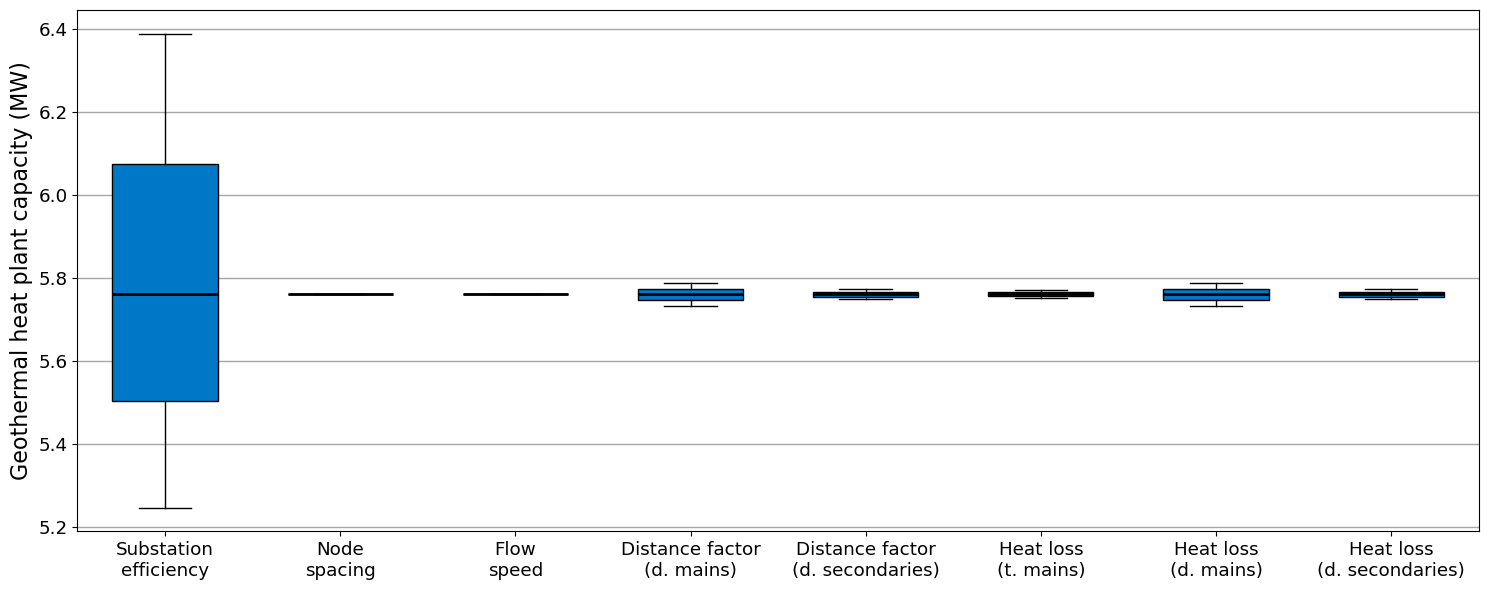


SUMMARY STATISTICS FOR ALL HEAT PARAMETERS

Substation efficiency:
  n=3, Mean=5.80 MW, Median=5.76 MW, Range=5.25-6.39 MW

Node spacing:
  n=3, Mean=5.76 MW, Median=5.76 MW, Range=5.76-5.76 MW

Flow speed:
  n=3, Mean=5.76 MW, Median=5.76 MW, Range=5.76-5.76 MW

Distance factor (d. mains):
  n=3, Mean=5.76 MW, Median=5.76 MW, Range=5.73-5.79 MW

Distance factor (d. secondaries):
  n=3, Mean=5.76 MW, Median=5.76 MW, Range=5.75-5.77 MW

Heat loss (t. mains):
  n=3, Mean=5.76 MW, Median=5.76 MW, Range=5.75-5.77 MW

Heat loss (d. mains):
  n=3, Mean=5.76 MW, Median=5.76 MW, Range=5.73-5.79 MW

Heat loss (d. secondaries):
  n=3, Mean=5.76 MW, Median=5.76 MW, Range=5.75-5.77 MW

All heat parameters sensitivity analysis complete!


In [33]:
# Sensitivity Analysis: All Heat Parameters vs Geothermal Capacity (District Heating)
# All boxplots combined on a single axis

if not dh_sensitivity.empty and not median_data.empty:
    print("\n" + "="*80)
    print("SENSITIVITY ANALYSIS: All Heat Parameters vs Geothermal Capacity")
    print("="*80)
    
    # Define all heat parameters from run_parallel.py with their values and labels
    heat_parameters = {
        'technology_parameters_heat_substation_eff': {
            'label': 'Substation\nefficiency',
            'values': [0.81, 0.9, 0.99],
            'median_value': 0.9
        },
        'scenario_info_spacing_m': {
            'label': 'Node\nspacing',
            'values': [2.5, 5.0, 10],
            'median_value': 5.0
        },
        'postprocessing_parameters_pipe_sizing_flow_speed': {
            'label': 'Flow\nspeed',
            'values': [0.56, 0.62, 0.68],
            'median_value': 0.62
        },
        'postprocessing_parameters_distance_factors_LQ heat distribution main': {
            'label': 'Distance factor\n(d. mains)',
            'values': [0.9, 1.0, 1.1],
            'median_value': 1.0
        },
        'postprocessing_parameters_distance_factors_LQ heat distribution secondary': {
            'label': 'Distance factor\n(d. secondaries)',
            'values': [0.9, 1.0, 1.1],
            'median_value': 1.0
        },
        'postprocessing_parameters_heat_loss_rates_Heat transmission main': {
            'label': 'Heat loss\n(t. mains)',
            'values': [59.2, 65.8, 72.4],
            'median_value': 65.8
        },
        'postprocessing_parameters_heat_loss_rates_LQ heat distribution main': {
            'label': 'Heat loss\n(d. mains)',
            'values': [46.8, 52, 57.2],
            'median_value': 52
        },
        'postprocessing_parameters_heat_loss_rates_LQ heat distribution secondary': {
            'label': 'Heat loss\n(d. secondaries)',
            'values': [26.1, 29, 31.9],
            'median_value': 29
        },
    }
    
    # Collect all boxplot data
    all_box_data = []
    all_box_labels = []
    
    for param_col, param_info in heat_parameters.items():
        param_label = param_info['label']
        param_values = param_info['values']
        median_value = param_info['median_value']
        
        print(f"\nParameter: {param_label.replace(chr(10), ' ')}")
        print(f"Analyzing values: {param_values}")
        
        if param_col in dh_sensitivity.columns:
            all_geothermal = []
            
            for i, param_value in enumerate(param_values):
                if param_value == median_value:
                    # For median, use the baseline median run (Multatulibuurt, DH, 2019, stedin topology)
                    median_multa_dh = median_data[
                        (median_data['neighborhood'] == 'multatulibuurt') & 
                        (median_data['scenario'] == 'district_heating') &
                        (median_data['year'] == 2019) &
                        (median_data['topology_source'] == 'stedin')
                    ]
                    
                    if not median_multa_dh.empty:
                        geothermal_capacity = median_multa_dh['results_summary_supply_geothermal_capacity_adjusted_kW'].dropna().values / 1000
                        all_geothermal.extend(geothermal_capacity)
                        print(f"  Median ({param_value}): n={len(geothermal_capacity)}, "
                              f"value={geothermal_capacity.mean():.2f} MW (from baseline median run, 2019, stedin)")
                    else:
                        print(f"  No baseline median run found for Multatulibuurt DH with stedin topology")
                else:
                    # For low and high, use sensitivity data
                    param_data = dh_sensitivity[dh_sensitivity[param_col] == param_value]
                    geothermal_capacity = param_data['results_summary_supply_geothermal_capacity_adjusted_kW'].dropna().values / 1000
                    
                    if len(geothermal_capacity) > 0:
                        all_geothermal.extend(geothermal_capacity)
                        label_text = 'Low' if i == 0 else 'High'
                    else:
                        print(f"  No data for value {param_value}")
            
            if len(all_geothermal) > 0:
                all_box_data.append(all_geothermal)
                all_box_labels.append(param_label)
                print(f"  Combined: n={len(all_geothermal)}, range={np.min(all_geothermal):.2f}-{np.max(all_geothermal):.2f} MW")
        else:
            print(f"  Column {param_col} not found in sensitivity data")
    
    # Create single figure with all boxplots on one axis
    if len(all_box_data) > 0:
        fig, ax = plt.subplots(figsize=(15, 6))
        
        bp = ax.boxplot(all_box_data, tick_labels=all_box_labels, patch_artist=True, widths=0.6)
        
        # Color the boxes with blue
        for patch in bp['boxes']:
            patch.set_facecolor('#0078c8')
        
        # Change median line color to black
        for median in bp['medians']:
            median.set(color='black', linewidth=2)
        
        # Set y-axis to linear scale and use regular numbers for ticks
        ax.set_yscale('linear')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
        
        # Add grid
        ax.grid(axis='y', alpha=0.7, linestyle='-', linewidth=1.0, color='gray')
        ax.set_axisbelow(True)
        
        # Format plot
        ax.set_ylabel('Geothermal heat plant capacity (MW)', fontsize=16)
        # Remove x-axis label and plot title
        #ax.set_xlabel('Heat Parameter', fontsize=13, fontweight='bold')
        #fig.suptitle('Multatulibuurt DH: Geothermal Capacity Sensitivity to All Heat Parameters', fontsize=14, fontweight='bold')
        ax.tick_params(axis='both', labelsize=12)
        
        # Increase x-axis tick label font size by 20%
        for label in ax.get_xticklabels():
            label.set_fontsize(label.get_fontsize() * 1.1)
        # Increase y-axis tick label font size by 20%
        for label in ax.get_yticklabels():
            label.set_fontsize(label.get_fontsize() * 1.1)
        
        # Rotate x-axis labels for better readability
        plt.xticks(rotation=0, ha='center')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics for all parameters
        print("\n" + "="*80)
        print("SUMMARY STATISTICS FOR ALL HEAT PARAMETERS")
        print("="*80)
        for i, (data, label) in enumerate(zip(all_box_data, all_box_labels)):
            clean_label = label.replace('\n', ' ')
            print(f"\n{clean_label}:")
            print(f"  n={len(data)}, Mean={np.mean(data):.2f} MW, "
                  f"Median={np.median(data):.2f} MW, "
                  f"Range={np.min(data):.2f}-{np.max(data):.2f} MW")
        
        print("\n" + "="*80)
        print("All heat parameters sensitivity analysis complete!")
        print("="*80)
    else:
        print("No data available for visualization")
else:
    print("No district heating sensitivity data available for Multatulibuurt")


SENSITIVITY ANALYSIS: All Electricity Parameters vs LV Electricity Supply (After Losses)


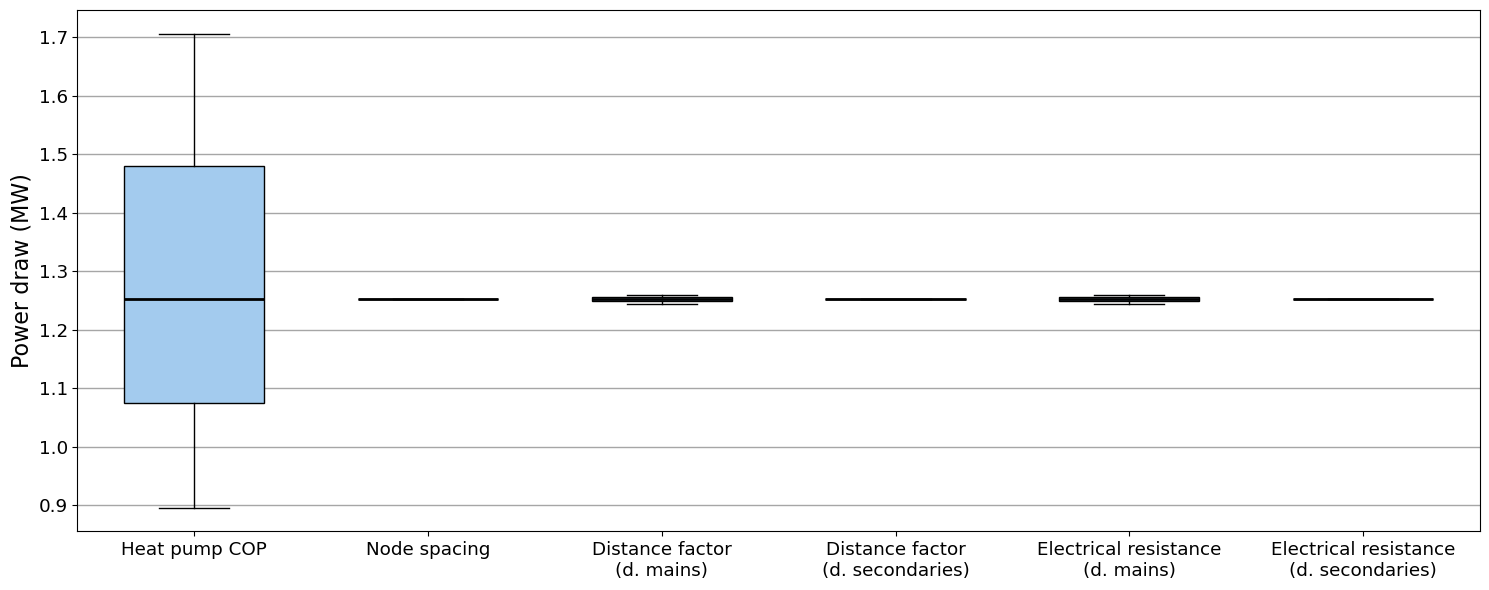


SUMMARY STATISTICS FOR ALL ELECTRICITY PARAMETERS

Heat pump COP:
  n=3, Mean=1.28 MW, Median=1.25 MW, Range=0.90-1.71 MW

Node spacing:
  n=3, Mean=1.25 MW, Median=1.25 MW, Range=1.25-1.25 MW

Distance factor (d. mains):
  n=3, Mean=1.25 MW, Median=1.25 MW, Range=1.25-1.26 MW

Distance factor (d. secondaries):
  n=3, Mean=1.25 MW, Median=1.25 MW, Range=1.25-1.25 MW

Electrical resistance (d. mains):
  n=3, Mean=1.25 MW, Median=1.25 MW, Range=1.25-1.26 MW

Electrical resistance (d. secondaries):
  n=3, Mean=1.25 MW, Median=1.25 MW, Range=1.25-1.25 MW

All electricity parameters sensitivity analysis complete!


In [41]:
# Sensitivity Analysis: All Electricity Parameters vs LV Electricity Supply (Full Electrification)
# All boxplots combined on a single axis

# Use the correct mapping and available columns from the upstream cell
if not fe_sensitivity.empty:
    print("\n" + "="*80)
    print("SENSITIVITY ANALYSIS: All Electricity Parameters vs LV Electricity Supply (After Losses)")
    print("="*80)
    
    # Use the mapping from the upstream cell, now including node spacing
    elec_params_mapping = {
        'technology_parameters_heat_pump_cop': 'Heat pump COP',
        'scenario_info_spacing_m': 'Node spacing',
        'postprocessing_parameters_distance_factors_LV electricity distribution main': 'Distance factor\n(d. mains)',
        'postprocessing_parameters_distance_factors_LV electricity distribution secondary': 'Distance factor\n(d. secondaries)',
        'postprocessing_parameters_electricity_resistance_rates_LV electricity distribution main': 'Electrical resistance\n(d. mains)',
        'postprocessing_parameters_electricity_resistance_rates_LV electricity distribution secondary': 'Electrical resistance\n(d. secondaries)',
    }
    # Parameter values for each (from run_parallel.py)
    elec_param_values = {
        'technology_parameters_heat_pump_cop': [3, 4.0, 5.5],
        'scenario_info_spacing_m': [2.5, 5.0, 10],
        'postprocessing_parameters_distance_factors_LV electricity distribution main': [0.9, 1.0, 1.1],
        'postprocessing_parameters_distance_factors_LV electricity distribution secondary': [0.9, 1.0, 1.1],
        'postprocessing_parameters_electricity_resistance_rates_LV electricity distribution main': [0.222, 0.247, 0.272],
        'postprocessing_parameters_electricity_resistance_rates_LV electricity distribution secondary': [0.222, 0.247, 0.272],
    }
    elec_param_median = {
        'technology_parameters_heat_pump_cop': 4.0,
        'scenario_info_spacing_m': 5.0,
        'postprocessing_parameters_distance_factors_LV electricity distribution main': 1.0,
        'postprocessing_parameters_distance_factors_LV electricity distribution secondary': 1.0,
        'postprocessing_parameters_electricity_resistance_rates_LV electricity distribution main': 0.247,
        'postprocessing_parameters_electricity_resistance_rates_LV electricity distribution secondary': 0.247,
    }
    
    all_box_data = []
    all_box_labels = []
    
    for param_col, param_label in elec_params_mapping.items():
        param_values = elec_param_values[param_col]
        median_value = elec_param_median[param_col]
        #print(f"\nParameter: {param_label}")
        #print(f"Analyzing values: {param_values}")
        if param_col in fe_sensitivity.columns:
            all_lv_elec = []
            for i, param_value in enumerate(param_values):
                if param_value == median_value:
                    # For median, use the baseline median run (Multatulibuurt, FE, 2019, stedin topology)
                    median_multa_fe = median_data[
                        (median_data['neighborhood'] == 'multatulibuurt') &
                        (median_data['scenario'] == 'full_electrification') &
                        (median_data['year'] == 2019) &
                        (median_data['topology_source'] == 'stedin')
                    ]
                    if not median_multa_fe.empty:
                        lv_col = 'results_summary_supply_LV_electricity_capacity_adjusted_kW' if 'results_summary_supply_LV_electricity_capacity_adjusted_kW' in median_multa_fe.columns else 'results_summary_supply_LV_electricity_capacity_kW'
                        lv_electricity = median_multa_fe[lv_col].dropna().values / 1000
                        all_lv_elec.extend(lv_electricity)
                        #print(f"  Median ({param_value}): n={len(lv_electricity)}, value={lv_electricity.mean():.2f} MW (from baseline median run, 2019, stedin)")
                    else:
                        print(f"  No baseline median run found for Multatulibuurt FE with stedin topology")
                else:
                    param_data = fe_sensitivity[fe_sensitivity[param_col] == param_value]
                    lv_col = 'results_summary_supply_LV_electricity_capacity_adjusted_kW' if 'results_summary_supply_LV_electricity_capacity_adjusted_kW' in param_data.columns else 'results_summary_supply_LV_electricity_capacity_kW'
                    lv_electricity = param_data[lv_col].dropna().values / 1000
                    if len(lv_electricity) > 0:
                        all_lv_elec.extend(lv_electricity)
                        label_text = 'Low' if i == 0 else 'High'
                        #print(f"  {label_text} ({param_value}): n={len(lv_electricity)}, mean={lv_electricity.mean():.2f} MW, std={lv_electricity.std():.2f} MW")
                    else:
                        print(f"  No data for value {param_value}")
            if len(all_lv_elec) > 0:
                all_box_data.append(all_lv_elec)
                all_box_labels.append(param_label)
                #print(f"  Combined: n={len(all_lv_elec)}, range={np.min(all_lv_elec):.2f}-{np.max(all_lv_elec):.2f} MW")
        else:
            print(f"  Column {param_col} not found in sensitivity data")
    
    if len(all_box_data) > 0:
        fig, ax = plt.subplots(figsize=(15, 6))
        bp = ax.boxplot(all_box_data, tick_labels=all_box_labels, patch_artist=True, widths=0.6)
        for patch in bp['boxes']:
            patch.set_facecolor('#a3cbee')
        for median in bp['medians']:
            median.set(color='black', linewidth=2)
        ax.set_yscale('linear')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
        ax.grid(axis='y', alpha=0.7, linestyle='-', linewidth=1.0, color='gray')
        ax.set_axisbelow(True)
        ax.set_ylabel('Power draw (MW)', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
        for label in ax.get_xticklabels():
            label.set_fontsize(label.get_fontsize() * 1.1)
        for label in ax.get_yticklabels():
            label.set_fontsize(label.get_fontsize() * 1.1)
        plt.xticks(rotation=0, ha='center')
        plt.tight_layout()
        plt.show()
        print("\n" + "="*80)
        print("SUMMARY STATISTICS FOR ALL ELECTRICITY PARAMETERS")
        print("="*80)
        for i, (data, label) in enumerate(zip(all_box_data, all_box_labels)):
            clean_label = label.replace('\n', ' ')
            print(f"\n{clean_label}:")
            print(f"  n={len(data)}, Mean={np.mean(data):.2f} MW, Median={np.median(data):.2f} MW, Range={np.min(data):.2f}-{np.max(data):.2f} MW")
        print("\n" + "="*80)
        print("All electricity parameters sensitivity analysis complete!")
        print("="*80)
    else:
        print("No data available for visualization")
else:
    print("No full electrification sensitivity data available for Multatulibuurt")